# Exercise 5 - LLMs for Content Analysis
_By Abigail Hayes_

In this exercise we will look at content analysis and labelling using LLMs. We will also examine handling validation and inter-annotator agreement.

We will use the same LLM as in the last 2 weeks. **You will likely need to run this notebook on the BWUniCluster3.0 or on Google Colab to have enough GPU memory and compute.**

This exercise consists of two parts:
1. LLM Annotation
2. Performance analysis

## Setup

Follow the instructions from Exercise 3 for LLM setup. Make sure you are using the correct kernel is selected for this notebook.

You will need to install kagglehub in the terminal for downloading the dataset, or download it manually.

``source llm4ess_env/bin/activate``
``pip install kagglehub``

### Human annotation

Before we begin, please complete the following [survey](https://forms.gle/b75KKFM6vD2pcWER8). We will use this later for evaluating the model's responses.

## LLM Annotation

We are now familar with getting the LLM to provide us with responses to questions through prompting. The dataset we are using is from Kaggle and provides us with a [collection of news headlines](https://www.kaggle.com/datasets/rmisra/news-category-dataset).

First we download the data.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/ma/ma_ma/ma_ahayes/.cache/kagglehub/datasets/rmisra/news-category-dataset/versions/3


And then we get the same selection you have seen in the survey.

In [4]:
import pandas as pd
import os

file_path = os.path.join(path, "News_Category_Dataset_v3.json")
df = pd.read_json(file_path, lines=True)  
df = df[df['category']=='WORLD NEWS']

sample_df = df.sample(n=30, random_state=7) 

for hl in sample_df['headline']:
    print(hl)

European Human Rights Court Backs Belgium's Ban On Face Veils
Germany's Far-Right Party Set To Enter Parliament For The First Time
Beachgoer Killed By Shark Along Popular Western Australia Beach
Deadly Data Gaps: How Lack Of Information Harms Refugee Policy Making
Saudi Implosion: Succession, Hubris And An Obsession With Iran
Theresa May Criticizes Donald Trump's Charlottesville Comments
Yemen’s Calamity Is Of Damning Proportions
Canada Bans Keeping Whales, Dolphins In Captivity
Russia Uses New Hypersonic Missile For First Time In Ukraine
Poland Relents On Controversial Holocaust Law
Canada, Finland Mask Up To Play Russian Team Decimated By COVID
U.S. Holocaust Museum Revokes Human Rights Award Given To Aung San Suu Kyi
Ethiopia To Release All Political Prisoners In Bid To Foster Reconciliation
Multiple Rockets Crash Near U.S. Embassy In Baghdad Amid Anti-Government Protests
Merkel's Party No Longer Describing U.S. As A 'Friend'
Iran Starts Work On Advanced Centrifuges
Afghanistan Mark

In [5]:
system_prompt = "You are a sentiment classifier. Answer only with the label as a single word. The sentiment can be positive, negative or neutral."
user_question = ". What is the sentiment?"

user_prompts = []
for hl in sample_df['headline']:
    user_prompts.append(hl + user_question)

batch_inputs = [
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    for user_prompt in user_prompts
]

print(batch_inputs[0])

[{'role': 'system', 'content': 'You are a sentiment classifier. Answer only with the label as a single word. The sentiment can be positive, negative or neutral.'}, {'role': 'user', 'content': "European Human Rights Court Backs Belgium's Ban On Face Veils. What is the sentiment?"}]


In [1]:
from transformers import pipeline

pipe = pipeline("text-generation", model="allenai/OLMo-2-0425-1B-Instruct")

Device set to use cuda:0


In [10]:
from transformers import set_seed

for seed in range(1,4):
    set_seed(seed)
    
    outputs = pipe(batch_inputs, max_new_tokens=100)
    
    llm_label = []
    for conversation in outputs:
        reply = conversation[0]['generated_text'][-1]['content']

        if reply.lower() in ['positive','negative','neutral']:
            llm_label.append(reply.lower())
        else:
            llm_label.append('error')
            print(reply)
    sample_df['llm_'+str(seed)] = llm_label

sad
 posi


In [7]:
sample_df

,link,headline,category,short_description,authors,date,llm_1,llm_2,llm_3
30245,https://www.huffingtonpost.com/entry/belgium-n...,European Human Rights Court Backs Belgium's Ba...,WORLD NEWS,Women who repeatedly violate the ban can face ...,Carol Kuruvilla,2017-07-13,positive,positive,positive
24901,https://www.huffingtonpost.com/entry/germany-a...,Germany's Far-Right Party Set To Enter Parliam...,WORLD NEWS,"The Alternative for Germany party, or AfD, sho...",Nick Robins-Early,2017-09-18,positive,positive,negative
3695,https://www.huffpost.com/entry/fatal-cable-bea...,Beachgoer Killed By Shark Along Popular Wester...,WORLD NEWS,Police said they shot at the shark after seein...,Nina Golgowski,2020-11-22,negative,negative,negative
29744,https://www.huffingtonpost.com/entry/deadly-da...,Deadly Data Gaps: How Lack Of Information Harm...,WORLD NEWS,Why doesn’t the humanitarian system have a way...,"Charlotte Alfred, Refugees Deeply",2017-07-19,negative,negative,negative
31871,https://www.huffingtonpost.com/entry/saudi-imp...,"Saudi Implosion: Succession, Hubris And An Obs...",WORLD NEWS,"In 2015, upon becoming the King of Saudi Arabi...","Hossein Askari, ContributorProfessor of Busine...",2017-06-23,negative,negative,negative
27400,https://www.huffingtonpost.com/entry/theresa-m...,Theresa May Criticizes Donald Trump's Charlott...,WORLD NEWS,“I see no equivalence between those who propou...,Alana Horowitz Satlin,2017-08-16,negative,negative,negative
30401,https://www.huffingtonpost.com/entry/yemens-ca...,Yemen’s Calamity Is Of Damning Proportions,WORLD NEWS,It is hard to imagine that along with the cata...,"Alon Ben-Meir, ContributorSenior Fellow, Cente...",2017-07-12,negative,error,negative
6640,https://www.huffpost.com/entry/canada-ban-whal...,"Canada Bans Keeping Whales, Dolphins In Captivity",WORLD NEWS,The “Free Willy” bill will become law by the e...,Zi-Ann Lum,2019-06-11,negative,negative,positive
991,https://www.huffpost.com/entry/russia-ukraine-...,Russia Uses New Hypersonic Missile For First T...,WORLD NEWS,Ukrainian President Volodymyr Zelenskyy warned...,"CARA ANNA, AP",2022-03-19,negative,negative,neutral
8521,https://www.huffpost.com/entry/poland-legislat...,Poland Relents On Controversial Holocaust Law,WORLD NEWS,The law allowed up to three years in prison fo...,Michelle Lou,2018-06-27,neutral,neutral,neutral


## Performance analysis

First let us look at how many errors we got.

In [8]:
error_count = (sample_df[['llm_1', 'llm_2', 'llm_3']] == 'error').sum().sum()
print("Total 'error' count:", error_count)

Total 'error' count: 2


How often does the LLM always get the same label? Or all 3 different?

In [11]:
same_count = (sample_df['llm_1'] == sample_df['llm_2']) & (sample_df['llm_2'] == sample_df['llm_3'])
same_count = same_count.sum()

print("Number of rows where all 3 LLM outputs are identical:", same_count)

Number of rows where all 3 LLM outputs are identical: 18


In [12]:
all_different = (
    (sample_df['llm_1'] != sample_df['llm_2']) &
    (sample_df['llm_1'] != sample_df['llm_3']) &
    (sample_df['llm_2'] != sample_df['llm_3'])
)

count_all_different = all_different.sum()
print("Number of rows where all 3 LLM outputs differ:", count_all_different)


Number of rows where all 3 LLM outputs differ: 0


### Human annotator agreement

Now we would like to compare to our ground-truth. We will create this from the human annotated data, but we need to first look at how good this is...

In [13]:
human_data = pd.read_csv('News headline sentiment (Responses) - Form responses 1.csv')
selected_cols = human_data.columns[1:-2]
df_selected = human_data[selected_cols]
df_selected = df_selected.astype(str).apply(lambda col: col.str.lower())

# Transpose: columns become rows, rows become columns
human_df = pd.DataFrame({
    "headline": selected_cols
})

# Add each row from df_selected as a new column
for i, row in enumerate(df_selected.itertuples(index=False), 1):
    human_df[f"annotator_{i}"] = row

human_df

,headline,annotator_1,annotator_2,annotator_3,annotator_4,annotator_5,annotator_6
0,European Human Rights Court Backs Belgium's Ba...,neutral,positive,neutral,neutral,negative,neutral
1,Germany's Far-Right Party Set To Enter Parliam...,neutral,negative,negative,neutral,neutral,positive
2,Beachgoer Killed By Shark Along Popular Wester...,neutral,negative,negative,neutral,negative,negative
3,Deadly Data Gaps: How Lack Of Information Harm...,negative,negative,neutral,neutral,negative,negative
4,"Saudi Implosion: Succession, Hubris And An Obs...",negative,neutral,neutral,neutral,neutral,negative
5,Theresa May Criticizes Donald Trump's Charlott...,neutral,negative,neutral,neutral,neutral,negative
6,Yemen’s Calamity Is Of Damning Proportions,negative,negative,negative,neutral,negative,negative
7,"Canada Bans Keeping Whales, Dolphins In Captiv...",neutral,positive,positive,neutral,positive,negative
8,Russia Uses New Hypersonic Missile For First T...,neutral,neutral,neutral,neutral,negative,negative
9,Poland Relents On Controversial Holocaust Law,neutral,neutral,negative,neutral,neutral,positive


Now to look at agreement with Krippendorff's alpha. _Note: this version assumes that the answers are not ordered. For our example, we could argue either way._

In [19]:
import numpy as np

annotator_cols = [col for col in human_df.columns if col.startswith("annotator_")]
data = human_df[annotator_cols]

def k_alpha(data):
    # Get all unique categories
    categories = pd.unique(data.values.ravel())
    
    # Create one-hot encoding for categories
    one_hot = pd.get_dummies(data)
    
    # Convert to numpy
    one_hot = one_hot.to_numpy()
    
    n_items, n_annotators = data.shape
    
    # Total pairwise comparisons per item
    pairwise_counts = n_annotators * (n_annotators - 1)
    
    D_o = 0
    for row in data.to_numpy():
        # Count how many pairs disagree
        for i in range(n_annotators):
            for j in range(i+1, n_annotators):
                if row[i] != row[j]:
                    D_o += 1
    
    # Normalize by total pairs
    D_o /= (n_items * pairwise_counts)
    
    # Flatten all annotations
    all_labels = data.values.ravel()
    freqs = pd.Series(all_labels).value_counts(normalize=True)
    
    # Expected disagreement = 1 - sum of squared frequencies
    D_e = 1 - np.sum(freqs**2)
    
    alpha = 1 - D_o / D_e
    print("Krippendorff's alpha:", alpha)

k_alpha(data)

Krippendorff's alpha: 0.5220919747520287


A good value would be 0.8 or higher. We would find 0.67 or higher acceptable. When it is lower, this may indicate an issue with the instructions being provided to the annotators. In our example, it could be improved with examples or even just a definition of sentiment.

How many does everyone agree on? How does this compare to your guesses?

Number of rows with full agreement: 0


<Axes: xlabel='How many questions do you think everyone will agree on?'>

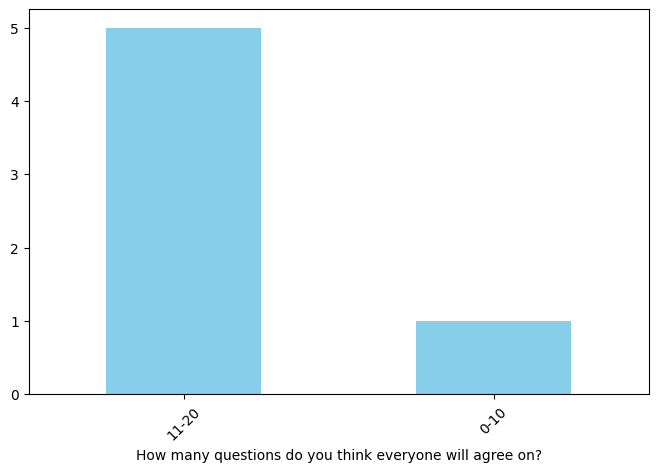

In [18]:
# Check if all values in the row are the same
full_agreement = human_df[annotator_cols].nunique(axis=1) == 1

# Count rows with full agreement
num_full_agreement = full_agreement.sum()

print("Number of rows with full agreement:", num_full_agreement)

human_data.iloc[:, -1].value_counts().plot.bar(figsize=(8,5), color='skyblue', rot=45)

### Task

Try out a method for selecting the human 'correct' label. What is the model performance?

What about if you only keep questions with high human performance? Or give some credit for matching with any human?

First we select the questions that we want to keep, and the human verdict that they receive. Here I have chosen to keep the question only when 2/3 or more of the annotators have agreed on a label. This is then taken as the majority verdict. Otherwise, we return None. We will then filter the data to remove those questions.

In [23]:
from collections import Counter

def majority_vote(row):
    counts = Counter(row)
    label, freq = counts.most_common(1)[0] # Keep most common category
    
    if freq >= len(row) * (2/3): # Require the chosen category to have 2/3 of the votes to be used
        return label
    else:
        return None  

human_df['majority_verdict'] = human_df[annotator_cols].apply(majority_vote, axis=1)
print(human_df[['headline', 'majority_verdict']])

                                             headline majority_verdict
0   European Human Rights Court Backs Belgium's Ba...          neutral
1   Germany's Far-Right Party Set To Enter Parliam...             None
2   Beachgoer Killed By Shark Along Popular Wester...         negative
3   Deadly Data Gaps: How Lack Of Information Harm...         negative
4   Saudi Implosion: Succession, Hubris And An Obs...          neutral
5   Theresa May Criticizes Donald Trump's Charlott...          neutral
6         Yemen’s Calamity Is Of Damning Proportions          negative
7   Canada Bans Keeping Whales, Dolphins In Captiv...             None
8   Russia Uses New Hypersonic Missile For First T...          neutral
9      Poland Relents On Controversial Holocaust Law           neutral
10  Canada, Finland Mask Up To Play Russian Team D...             None
11  U.S. Holocaust Museum Revokes Human Rights Awa...             None
12  Ethiopia To Release All Political Prisoners In...             None
13  Mu

In [33]:
human_final = human_df[human_df['majority_verdict'].notnull()]
human_final

,headline,annotator_1,annotator_2,annotator_3,annotator_4,annotator_5,annotator_6,majority_verdict
0,European Human Rights Court Backs Belgium's Ba...,neutral,positive,neutral,neutral,negative,neutral,neutral
2,Beachgoer Killed By Shark Along Popular Wester...,neutral,negative,negative,neutral,negative,negative,negative
3,Deadly Data Gaps: How Lack Of Information Harm...,negative,negative,neutral,neutral,negative,negative,negative
4,"Saudi Implosion: Succession, Hubris And An Obs...",negative,neutral,neutral,neutral,neutral,negative,neutral
5,Theresa May Criticizes Donald Trump's Charlott...,neutral,negative,neutral,neutral,neutral,negative,neutral
6,Yemen’s Calamity Is Of Damning Proportions,negative,negative,negative,neutral,negative,negative,negative
8,Russia Uses New Hypersonic Missile For First T...,neutral,neutral,neutral,neutral,negative,negative,neutral
9,Poland Relents On Controversial Holocaust Law,neutral,neutral,negative,neutral,neutral,positive,neutral
13,Multiple Rockets Crash Near U.S. Embassy In Ba...,neutral,negative,negative,neutral,negative,negative,negative
14,Merkel's Party No Longer Describing U.S. As A ...,neutral,negative,negative,neutral,negative,negative,negative


We do the same for the LLM, but simplified by knowing that there are never 3 different responses to a question. This means we always have a 2/3 majority or complete agreement.

In [ ]:
sample_df['llm_verdict'] = sample_df[['llm_1', 'llm_2', 'llm_3']].apply(majority_vote, axis=1)
sample_df

,link,headline,category,short_description,authors,date,llm_1,llm_2,llm_3,llm_verdict
30245,https://www.huffingtonpost.com/entry/belgium-n...,European Human Rights Court Backs Belgium's Ba...,WORLD NEWS,Women who repeatedly violate the ban can face ...,Carol Kuruvilla,2017-07-13,positive,positive,positive,positive
24901,https://www.huffingtonpost.com/entry/germany-a...,Germany's Far-Right Party Set To Enter Parliam...,WORLD NEWS,"The Alternative for Germany party, or AfD, sho...",Nick Robins-Early,2017-09-18,positive,positive,negative,positive
3695,https://www.huffpost.com/entry/fatal-cable-bea...,Beachgoer Killed By Shark Along Popular Wester...,WORLD NEWS,Police said they shot at the shark after seein...,Nina Golgowski,2020-11-22,negative,negative,negative,negative
29744,https://www.huffingtonpost.com/entry/deadly-da...,Deadly Data Gaps: How Lack Of Information Harm...,WORLD NEWS,Why doesn’t the humanitarian system have a way...,"Charlotte Alfred, Refugees Deeply",2017-07-19,negative,negative,negative,negative
31871,https://www.huffingtonpost.com/entry/saudi-imp...,"Saudi Implosion: Succession, Hubris And An Obs...",WORLD NEWS,"In 2015, upon becoming the King of Saudi Arabi...","Hossein Askari, ContributorProfessor of Busine...",2017-06-23,negative,negative,negative,negative
27400,https://www.huffingtonpost.com/entry/theresa-m...,Theresa May Criticizes Donald Trump's Charlott...,WORLD NEWS,“I see no equivalence between those who propou...,Alana Horowitz Satlin,2017-08-16,negative,negative,negative,negative
30401,https://www.huffingtonpost.com/entry/yemens-ca...,Yemen’s Calamity Is Of Damning Proportions,WORLD NEWS,It is hard to imagine that along with the cata...,"Alon Ben-Meir, ContributorSenior Fellow, Cente...",2017-07-12,negative,error,negative,negative
6640,https://www.huffpost.com/entry/canada-ban-whal...,"Canada Bans Keeping Whales, Dolphins In Captivity",WORLD NEWS,The “Free Willy” bill will become law by the e...,Zi-Ann Lum,2019-06-11,negative,negative,positive,negative
991,https://www.huffpost.com/entry/russia-ukraine-...,Russia Uses New Hypersonic Missile For First T...,WORLD NEWS,Ukrainian President Volodymyr Zelenskyy warned...,"CARA ANNA, AP",2022-03-19,negative,negative,neutral,negative
8521,https://www.huffpost.com/entry/poland-legislat...,Poland Relents On Controversial Holocaust Law,WORLD NEWS,The law allowed up to three years in prison fo...,Michelle Lou,2018-06-27,neutral,neutral,neutral,neutral


Just out of interest, we can look again at inter-annotator agreement between humans on the questions we are keeping. We know that the annotators are never unanimous, so the value will never be particularly high.

In [45]:
human_agree = human_final[annotator_cols]
k_alpha(human_agree)

Krippendorff's alpha: 0.5455417066155321


Now we can join together the 2 dataframes. There is a space at the end of the human annotator headlines, so we will remove that for joining.

In [44]:
human_final['headline'] = human_final['headline'].str.strip()
merged = pd.merge(sample_df, human_final, on='headline')
merged

/scratch/slurm_tmpdir/job_1728281/ipykernel_476167/1989616120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_final['headline'] = human_final['headline'].str.strip()


,link,headline,category,short_description,authors,date,llm_1,llm_2,llm_3,llm_verdict,annotator_1,annotator_2,annotator_3,annotator_4,annotator_5,annotator_6,majority_verdict
0,https://www.huffingtonpost.com/entry/belgium-n...,European Human Rights Court Backs Belgium's Ba...,WORLD NEWS,Women who repeatedly violate the ban can face ...,Carol Kuruvilla,2017-07-13,positive,positive,positive,positive,neutral,positive,neutral,neutral,negative,neutral,neutral
1,https://www.huffpost.com/entry/fatal-cable-bea...,Beachgoer Killed By Shark Along Popular Wester...,WORLD NEWS,Police said they shot at the shark after seein...,Nina Golgowski,2020-11-22,negative,negative,negative,negative,neutral,negative,negative,neutral,negative,negative,negative
2,https://www.huffingtonpost.com/entry/deadly-da...,Deadly Data Gaps: How Lack Of Information Harm...,WORLD NEWS,Why doesn’t the humanitarian system have a way...,"Charlotte Alfred, Refugees Deeply",2017-07-19,negative,negative,negative,negative,negative,negative,neutral,neutral,negative,negative,negative
3,https://www.huffingtonpost.com/entry/saudi-imp...,"Saudi Implosion: Succession, Hubris And An Obs...",WORLD NEWS,"In 2015, upon becoming the King of Saudi Arabi...","Hossein Askari, ContributorProfessor of Busine...",2017-06-23,negative,negative,negative,negative,negative,neutral,neutral,neutral,neutral,negative,neutral
4,https://www.huffingtonpost.com/entry/theresa-m...,Theresa May Criticizes Donald Trump's Charlott...,WORLD NEWS,“I see no equivalence between those who propou...,Alana Horowitz Satlin,2017-08-16,negative,negative,negative,negative,neutral,negative,neutral,neutral,neutral,negative,neutral
5,https://www.huffingtonpost.com/entry/yemens-ca...,Yemen’s Calamity Is Of Damning Proportions,WORLD NEWS,It is hard to imagine that along with the cata...,"Alon Ben-Meir, ContributorSenior Fellow, Cente...",2017-07-12,negative,error,negative,negative,negative,negative,negative,neutral,negative,negative,negative
6,https://www.huffpost.com/entry/russia-ukraine-...,Russia Uses New Hypersonic Missile For First T...,WORLD NEWS,Ukrainian President Volodymyr Zelenskyy warned...,"CARA ANNA, AP",2022-03-19,negative,negative,neutral,negative,neutral,neutral,neutral,neutral,negative,negative,neutral
7,https://www.huffpost.com/entry/poland-legislat...,Poland Relents On Controversial Holocaust Law,WORLD NEWS,The law allowed up to three years in prison fo...,Michelle Lou,2018-06-27,neutral,neutral,neutral,neutral,neutral,neutral,negative,neutral,neutral,positive,neutral
8,https://www.huffpost.com/entry/rockets-us-emba...,Multiple Rockets Crash Near U.S. Embassy In Ba...,WORLD NEWS,Hundreds of anti-government demonstrators floo...,,2020-01-26,negative,negative,negative,negative,neutral,negative,negative,neutral,negative,negative,negative
9,https://www.huffingtonpost.com/entry/merkels-p...,Merkel's Party No Longer Describing U.S. As A ...,WORLD NEWS,The change in wording underscores how relation...,"Noah Barkin, Reuters",2017-07-03,negative,negative,negative,negative,neutral,negative,negative,neutral,negative,negative,negative


Finally we look at some comparison between the human and llm labels. When we are confident in the 'true' labels, this might be accuracy or another similar measure. For our example, we can just look at the level of agreement with the same metric as for the annotators within the groups.

In [46]:
final_compare = merged[['majority_verdict', 'llm_verdict']]
k_alpha(final_compare)

Krippendorff's alpha: 0.5975855130784709
